# Dualidad en transporte óptimo

En este cuaderno exploraremos computacionalmente la **dualidad de Kantorovich**.

Este cuaderno acompaña los **Capítulos 3 a 6** de las notas (*dualidad en programación lineal*, *dualidad de Kantorovich*, *potenciales en el caso discreto* y *potenciales de Kantorovich*). Resolvemos numéricamente el problema primal y el dual para medidas discretas, verificamos las restricciones duales y su saturación sobre el soporte del plan óptimo, calculamos las $c$-transformadas, y después estudiamos con ejemplos pequeños la unicidad de los potenciales, la iteración de mejora de potenciales y el costo $0$--$1$. Los **ejercicios computacionales** están al final y sus enunciados figuran también en las notas.


Partimos de un problema de transporte entre dos medidas discretas
$$
\mu=\sum_{i=1}^n a_i\delta_{x_i},
\qquad
\nu=\sum_{j=1}^n b_j\delta_{y_j},
$$
y consideramos el problema primal de Kantorovich
$$
\min_{\pi\in\Pi(\mu,\nu)}
\sum_{i,j} c_{ij}\pi_{ij},
$$
donde
$$
c_{ij}=c(x_i,y_j).
$$

La teoría de dualidad nos dice que este problema puede formularse
también mediante el problema dual
$$
\max_{\varphi,\psi}
\left\{
\sum_i a_i\varphi_i+\sum_j b_j\psi_j
:
\varphi_i+\psi_j\leq c_{ij}
\right\}.
$$

En este notebook resolveremos ambos problemas numéricamente y
compararemos sus valores óptimos. Luego utilizaremos los potenciales
duales para explorar algunas de las propiedades que aparecen en la
teoría.

In [2]:
# @title
pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 63.9 MB/s eta 0:00:00


## 1. Resolución del problema primal

Comenzamos con el problema de transporte entre las medidas discretas
$$
\mu=\sum_{i=1}^n a_i\delta_{x_i},
\qquad
\nu=\sum_{j=1}^n b_j\delta_{y_j},
$$
que ya utilizamos en el notebook anterior.

En este ejemplo tomamos como función de costo
$$
c(x,y)=|x-y|^2.
$$

Construimos la matriz de costos
$$
c_{ij}=c(x_i,y_j)=|x_i-y_j|^2.
$$

El problema primal de Kantorovich consiste en encontrar una matriz
$$
\pi=(\pi_{ij})_{i,j=1}^n
$$
que satisfaga las condiciones de marginalidad
$$
\sum_j\pi_{ij}=a_i,
\qquad
\sum_i\pi_{ij}=b_j,
$$
y que minimice el costo total
$$
\sum_{i,j}c_{ij}\pi_{ij}.
$$

Utilizamos la función `ot.emd` de la biblioteca **POT** para calcular
numéricamente un plan de transporte óptimo $\pi$.

Finalmente, calculamos el valor óptimo del problema primal:
$$
\min_{\pi\in\Pi(\mu,\nu)}
\sum_{i,j}c_{ij}\pi_{ij}.
$$

In [3]:
# @title
import numpy as np
import ot
from scipy.spatial.distance import cdist

# ==========================================================
# Datos
# ==========================================================

np.random.seed(3)

n = 20

X = np.random.rand(n,2)
Y = np.random.rand(n,2)

a = np.random.rand(n)
a /= a.sum()

b = np.random.rand(n)
b /= b.sum()

# Costo cuadrático
C = cdist(X, Y, metric="sqeuclidean")

# ==========================================================
# Plan óptimo primal
# ==========================================================

pi = ot.emd(a, b, C)

primal_cost = np.sum(pi*C)

print(f"Valor óptimo primal = {primal_cost:.6f}")

Valor óptimo primal = 0.039025


## 2. Resolución del problema dual

Ahora resolvemos numéricamente el problema dual de Kantorovich asociado
al problema de transporte anterior.

En el caso discreto, el problema dual consiste en encontrar dos familias
de números
$$
\varphi_1,\ldots,\varphi_n,
\qquad
\psi_1,\ldots,\psi_n,
$$
que maximicen
$$
\sum_i a_i\varphi_i+\sum_j b_j\psi_j
$$
sujeto a las restricciones
$$
\varphi_i+\psi_j\leq c_{ij},
\qquad
1\leq i,j\leq n.
$$

Los números $\varphi_i$ y $\psi_j$ son los valores de los
**potenciales de Kantorovich** en los puntos $x_i$ e $y_j$,
respectivamente.

Para resolver este problema utilizamos `scipy.optimize.linprog`.
Como esta función está formulada para minimizar una función lineal,
resolvemos el negativo del funcional objetivo:
$$
-\sum_i a_i\varphi_i-\sum_j b_j\psi_j.
$$

Las restricciones del problema dual se escriben como un sistema de
desigualdades lineales
$$
\varphi_i+\psi_j\leq c_{ij}.
$$

No imponemos restricciones de signo sobre los potenciales:
los valores $\varphi_i$ y $\psi_j$ pueden ser positivos o negativos.

Una vez resuelto el problema, obtenemos los potenciales óptimos
$\varphi$ y $\psi$ y calculamos el valor óptimo del problema dual:
$$
\max_{\varphi,\psi}
\left\{
\sum_i a_i\varphi_i+\sum_j b_j\psi_j
:
\varphi_i+\psi_j\leq c_{ij}
\right\}.
$$

In [4]:
# @title
import numpy as np
from scipy.optimize import linprog

# ==========================================================
# Problema dual de Kantorovich
# ==========================================================

# Variables:
#   phi_1,...,phi_n, psi_1,...,psi_n

# Función objetivo:
#   maximizar sum_i a_i phi_i + sum_j b_j psi_j
#
# scipy.optimize.linprog minimiza, por lo que usamos el negativo.

c_dual = -np.concatenate((a, b))

# Restricciones:
#   phi_i + psi_j <= C_ij

A_ub = np.zeros((n*n, 2*n))
b_ub = np.zeros(n*n)

k = 0

for i in range(n):
    for j in range(n):

        A_ub[k, i] = 1
        A_ub[k, n+j] = 1

        b_ub[k] = C[i,j]

        k += 1

# Sin restricciones de signo:
# los potenciales pueden ser positivos o negativos.

bounds = [(None, None)]*(2*n)

# Resolver
result = linprog(
    c_dual,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

phi = result.x[:n]
psi = result.x[n:]

dual_cost = -result.fun

print(f"Valor óptimo del problema dual = {dual_cost:.6f}")

Valor óptimo del problema dual = 0.039025


## 3. Visualización de los potenciales duales

Una vez resuelto el problema dual, podemos visualizar los potenciales
óptimos $\varphi$ y $\psi$ sobre los puntos de origen $x_i$ y destino
$y_j$.

Cada punto se colorea de acuerdo con el valor del potencial correspondiente.

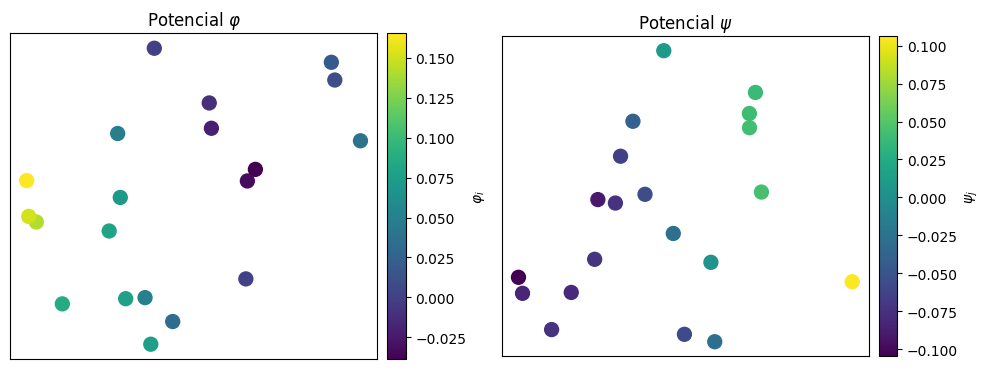

In [6]:
# @title
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ==========================================================
# Visualización de los potenciales duales
# ==========================================================

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# ----------------------------------------------------------
# Potencial phi sobre los puntos de origen
# ----------------------------------------------------------

sc1 = axs[0].scatter(
    X[:,0], X[:,1],
    c=phi,
    s=100,
    cmap="viridis"
)

axs[0].set_aspect("equal")
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title(r"Potencial $\varphi$")

divider = make_axes_locatable(axs[0])
cax1 = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(sc1, cax=cax1, label=r"$\varphi_i$")

# ----------------------------------------------------------
# Potencial psi sobre los puntos de destino
# ----------------------------------------------------------

sc2 = axs[1].scatter(
    Y[:,0], Y[:,1],
    c=psi,
    s=100,
    cmap="viridis"
)

axs[1].set_aspect("equal")
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title(r"Potencial $\psi$")

divider = make_axes_locatable(axs[1])
cax2 = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(sc2, cax=cax2, label=r"$\psi_j$")

plt.tight_layout()
plt.show()

## 4. Verificación de las restricciones duales

Los potenciales $\varphi$ y $\psi$ obtenidos al resolver el problema
dual deben satisfacer, para todo par de puntos $(x_i,y_j)$, la restricción
$$
\varphi_i+\psi_j\leq c_{ij}.
$$

Para verificarlo numéricamente, definimos la **holgura dual**
$$
R_{ij}=c_{ij}-\varphi_i-\psi_j.
$$

La factibilidad del par $(\varphi,\psi)$ implica entonces que
$$
R_{ij}\geq 0
$$
para todos $i,j$.

En la práctica, debido a los errores de redondeo, la holgura mínima
puede presentar un pequeño valor negativo. Valores de este orden
corresponden a cero dentro de la precisión numérica.

Visualizaremos la matriz $R$ para comprobar que las restricciones
duales se satisfacen y analizar su estructura.

Holgura mínima = -5.55e-17
Holgura máxima = 1.24


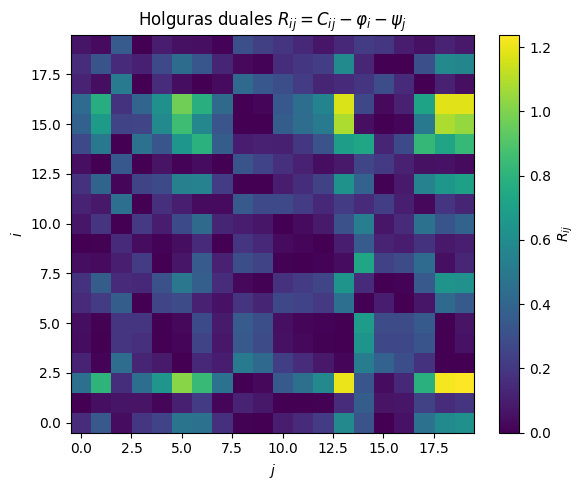

In [7]:
# @title
import matplotlib.pyplot as plt

# ==========================================================
# Holguras de las restricciones duales
# ==========================================================

R = C - phi[:, None] - psi[None, :]

print(f"Holgura mínima = {R.min():.2e}")
print(f"Holgura máxima = {R.max():.2f}")

# ==========================================================
# Visualización
# ==========================================================

plt.figure(figsize=(6,5))

im = plt.imshow(
    R,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.xlabel(r"$j$")
plt.ylabel(r"$i$")
plt.title(r"Holguras duales $R_{ij}=C_{ij}-\varphi_i-\psi_j$")

plt.colorbar(im, label=r"$R_{ij}$")

plt.tight_layout()
plt.show()

## 5. Saturación de las restricciones duales

La dualidad fuerte establece que el valor óptimo del problema primal
coincide con el del problema dual. Pero, para un plan óptimo $\pi$ y
unos potenciales duales óptimos $\varphi,\psi$, existe además una
relación más precisa entre ambas soluciones.

Recordemos que las restricciones duales son
$$
\varphi_i+\psi_j\leq c_{ij},
$$
o, equivalentemente,
$$
R_{ij}=c_{ij}-\varphi_i-\psi_j\geq 0.
$$

Por otro lado, si $\pi_{ij}>0$, entonces en un par óptimo
$(\pi,\varphi,\psi)$ debe cumplirse
$$
\varphi_i+\psi_j=c_{ij}.
$$
Es decir, las restricciones duales se **saturan sobre el soporte del
plan óptimo**:
$$
\pi_{ij}>0
\quad\Longrightarrow\quad
R_{ij}=0.
$$

Esta es la versión discreta de la condición
$$
\varphi(x)+\psi(y)=c(x,y)
\qquad \pi^*\text{-c.t.p.}
$$

En la siguiente celda verificaremos numéricamente esta propiedad,
calculando las holguras únicamente en aquellos pares $(i,j)$ para los
cuales el plan óptimo transporta una cantidad positiva de masa.

In [8]:
# @title
# ==========================================================
# Saturación sobre el soporte del plan óptimo
# ==========================================================

threshold = 1e-10

# Pares (i,j) donde el plan óptimo transporta masa
mask = pi > threshold

# Holguras sobre el soporte de pi
R_support = R[mask]

print(f"Número de pares con pi_ij > {threshold}: {len(R_support)}")
print(
    f"Máxima holgura sobre el soporte de pi = "
    f"{np.max(np.abs(R_support)):.2e}"
)

Número de pares con pi_ij > 1e-10: 39
Máxima holgura sobre el soporte de pi = 5.55e-17


## 6. Visualización de la saturación

Podemos visualizar conjuntamente las holguras duales y el soporte del
plan óptimo.

El mapa de calor representa la matriz
$$
R_{ij}=c_{ij}-\varphi_i-\psi_j,
$$
mientras que marcaremos los pares $(i,j)$ para los cuales
$$
\pi_{ij}>0.
$$

De acuerdo con la relación
$$
\pi_{ij}>0
\quad\Longrightarrow\quad
\varphi_i+\psi_j=c_{ij},
$$
esperamos que los puntos correspondientes al soporte de $\pi$ se
encuentren precisamente en las entradas donde la holgura $R_{ij}$ se
anula.

Esta visualización permite ver de manera directa la relación entre el
plan óptimo y los potenciales duales.

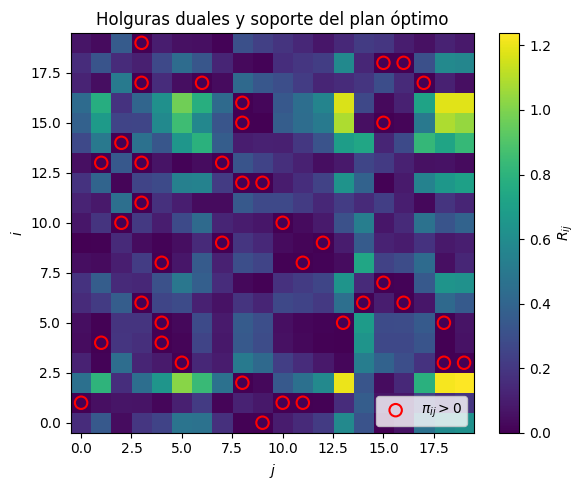

In [9]:
# @title
# ==========================================================
# Soporte del plan óptimo sobre las holguras duales
# ==========================================================

plt.figure(figsize=(6,5))

# Holguras duales
im = plt.imshow(
    R,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

# Soporte del plan óptimo
i_support, j_support = np.where(pi > 1e-10)

plt.scatter(
    j_support,
    i_support,
    facecolors="none",
    edgecolors="red",
    s=80,
    linewidths=1.5,
    label=r"$\pi_{ij}>0$"
)

plt.xlabel(r"$j$")
plt.ylabel(r"$i$")
plt.title(r"Holguras duales y soporte del plan óptimo")

plt.colorbar(im, label=r"$R_{ij}$")
plt.legend()

plt.tight_layout()
plt.show()

### Una observación importante

La condición
$$
\pi_{ij}>0
\quad\Longrightarrow\quad
\varphi_i+\psi_j=c_{ij}
$$
es una implicación en una sola dirección. Por lo tanto, su recíproca no tiene por qué ser cierta.

Puede ocurrir que
$$
\varphi_i+\psi_j=c_{ij}
$$
pero que
$$
\pi_{ij}=0.
$$

En otras palabras, el soporte del plan óptimo está contenido en el conjunto
donde las restricciones duales se saturan:
$$
\operatorname{supp}(\pi)
\subset
\left\{(i,j):\varphi_i+\psi_j=c_{ij}\right\}.
$$

El plan óptimo utiliza únicamente pares $(i,j)$ donde la restricción dual
está saturada, pero no necesariamente utiliza todos los pares donde se
produce dicha saturación.

En la figura anterior se observan también algunos pares $(i,j)$ para los
cuales $\pi_{ij}=0$ y, sin embargo,
$$
\varphi_i+\psi_j=c_{ij},
$$
es decir, la holgura dual también se anula. Esto muestra que la recíproca
de la implicación anterior no tiene por qué ser cierta.

## 7. Las c-transformadas de los potenciales óptimos

Los potenciales óptimos $\varphi$ y $\psi$ no son independientes entre sí.
La teoría de la c-concavidad establece que, en un par dual óptimo,
cada potencial puede recuperarse a partir del otro mediante la **c-transformada**.

En el caso discreto, la c-transformada de $\varphi$ es
$$
\varphi^c_j = \min_i\,\bigl(c_{ij}-\varphi_i\bigr),
$$
y la c-transformada conjugada de $\psi$ es
$$
\psi^{\bar c}_i = \min_j\,\bigl(c_{ij}-\psi_j\bigr).
$$

La teoría garantiza que, para potenciales óptimos, se cumple
$$
\psi = \varphi^c,
\qquad
\varphi = \psi^{\bar c}.
$$

Verifiquemos esto numéricamente.


In [ ]:
# @title
# ==========================================================
# c-transformadas de los potenciales óptimos
# ==========================================================

# phi^c_j = min_i (C_ij - phi_i)
phi_c = np.min(C - phi[:, None], axis=0)   # shape (n,)

# psi^{c_bar}_i = min_j (C_ij - psi_j)
psi_cbar = np.min(C - psi[None, :], axis=1) # shape (n,)

print("Verificación de phi^c = psi:")
print(f"  Error máximo: {np.max(np.abs(phi_c - psi)):.2e}")

print("Verificación de psi^cbar = phi:")
print(f"  Error máximo: {np.max(np.abs(psi_cbar - phi)):.2e}")

# ==========================================================
# Visualización
# ==========================================================

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# phi^c vs psi
axs[0].scatter(phi_c, psi, s=60, zorder=3)
lims = [min(phi_c.min(), psi.min()), max(phi_c.max(), psi.max())]
axs[0].plot(lims, lims, 'r--', lw=1.5, label='identidad')
axs[0].set_xlabel(r"$\varphi^c_j$")
axs[0].set_ylabel(r"$\psi_j$")
axs[0].set_title(r"$\varphi^c = \psi$")
axs[0].legend()
axs[0].grid(alpha=0.3)

# psi^cbar vs phi
axs[1].scatter(psi_cbar, phi, s=60, zorder=3)
lims2 = [min(psi_cbar.min(), phi.min()), max(psi_cbar.max(), phi.max())]
axs[1].plot(lims2, lims2, 'r--', lw=1.5, label='identidad')
axs[1].set_xlabel(r"$\psi^{\bar c}_i$")
axs[1].set_ylabel(r"$\varphi_i$")
axs[1].set_title(r"$\psi^{\bar c} = \varphi$")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Un problema $2\times2$ a mano

Antes de los ejemplos aleatorios conviene tener uno que se pueda resolver completamente a mano (Ejercicio 3.3 de las notas): $a=(0{,}4,\,0{,}6)$, $b=(0{,}5,\,0{,}5)$ y costos $c=\bigl(\begin{smallmatrix}1&3\\2&1\end{smallmatrix}\bigr)$. El politopo $\Pi(a,b)$ tiene un solo grado de libertad, $\pi_{11}=t\in[0,0{,}4]$, así que podemos graficar el costo como función de $t$, resolver el dual y verificar la dualidad fuerte y la holgura complementaria. Los pares duales óptimos forman una recta $(\varphi+s,\psi-s)$: la invariancia por sumar una constante a $\varphi$ y restársela a $\psi$.

In [ ]:
# @title
import numpy as np, matplotlib.pyplot as plt, ot
from scipy.optimize import linprog

a2 = np.array([0.4, 0.6]); b2 = np.array([0.5, 0.5]); C2 = np.array([[1., 3.], [2., 1.]])

# el segmento Pi(a,b): pi = [[t, 0.4-t],[0.5-t, 0.1+t]], t in [0, 0.4]
ts = np.linspace(0, 0.4, 101)
costo = [np.sum(C2*np.array([[t, 0.4-t], [0.5-t, 0.1+t]])) for t in ts]
plt.figure(figsize=(5, 3.2)); plt.plot(ts, costo); plt.xlabel(r'$t=\pi_{11}$'); plt.ylabel('costo'); plt.title('Costo sobre el segmento $\\Pi(a,b)$'); plt.show()

pi2 = ot.emd(a2, b2, C2)
print("plan óptimo:\n", pi2, "\ncosto óptimo primal =", np.sum(C2*pi2))

# dual: max a.phi + b.psi  s.a.  phi_i + psi_j <= c_ij ; normalizamos psi_1 = 0
A_ub = np.array([[1, 0, 1, 0], [1, 0, 0, 1], [0, 1, 1, 0], [0, 1, 0, 1]], float)
res = linprog(-np.concatenate([a2, b2]), A_ub=A_ub, b_ub=C2.ravel(), bounds=[(None, None)]*3 + [(None, None)], A_eq=[[0, 0, 1, 0]], b_eq=[0], method='highs')
phi2, psi2 = res.x[:2], res.x[2:]
print(f"potenciales (con psi_1 = 0): phi = {phi2}, psi = {psi2},  valor dual = {-res.fun:.4f}")
print("holgura complementaria: pi_ij > 0  =>  phi_i + psi_j = c_ij:")
for i in range(2):
    for j in range(2):
        print(f"   ({i+1},{j+1}): pi = {pi2[i,j]:.1f}, holgura c_ij - phi_i - psi_j = {C2[i,j]-phi2[i]-psi2[j]:.4f}")

## 9. Potenciales no únicos y el grafo de soporte

En el ejemplo aleatorio de las secciones anteriores los potenciales óptimos son únicos salvo la constante $(\varphi+s,\psi-s)$. Eso no siempre ocurre. El Ejercicio 5.1 de las notas propone $x_i=y_i=i-1$ ($i=1,2,3$), $a=(\frac12,\frac14,\frac14)$, $b=(\frac14,\frac14,\frac12)$, costo cuadrático: el plan óptimo tiene soporte $\{(1,1),(1,2),(2,3),(3,3)\}$, cuyo **grafo bipartito** tiene dos componentes conexas, $\{x_1,y_1,y_2\}$ y $\{x_2,x_3,y_3\}$, y por eso los potenciales tienen un grado de libertad adicional: normalizando $\varphi_1=0$ forman el segmento $\varphi=(0,1-t,-t)$, $\psi=(0,1,t)$, $t\in[2,4]$.

Para calcular numéricamente **todo** el conjunto de pares óptimos, resolvemos dos programas lineales auxiliares: maximizar y minimizar $\psi_3$ sujeto a las restricciones duales y a que el valor dual sea el óptimo. Después contamos las componentes conexas del grafo de soporte.

In [ ]:
# @title
x3 = np.array([0., 1., 2.]); a3 = np.array([.5, .25, .25]); b3 = np.array([.25, .25, .5])
C3 = (x3[:, None] - x3[None, :])**2
pi3 = ot.emd(a3, b3, C3); OT3 = np.sum(C3*pi3)
print("plan óptimo (x4):\n", np.round(4*pi3).astype(int), "\ncosto óptimo =", OT3)

n = 3
def dual_lp(objetivo, valor_optimo=None):
    # variables (phi_1..phi_3, psi_1..psi_3); normalizacion phi_1 = 0
    A_ub = np.zeros((n*n, 2*n)); b_ub = np.zeros(n*n); k = 0
    for i in range(n):
        for j in range(n):
            A_ub[k, i] = 1; A_ub[k, n+j] = 1; b_ub[k] = C3[i, j]; k += 1
    A_eq = [[1, 0, 0, 0, 0, 0]]; b_eq = [0]
    if valor_optimo is not None:
        A_eq.append(list(np.concatenate([a3, b3]))); b_eq.append(valor_optimo)
    r = linprog(objetivo, A_ub=A_ub, b_ub=b_ub, A_eq=np.array(A_eq, float), b_eq=b_eq, bounds=[(None, None)]*(2*n), method='highs')
    return r

r = dual_lp(-np.concatenate([a3, b3]))
print("valor dual óptimo =", -r.fun)
e6 = np.zeros(6); e6[5] = 1
tmin = dual_lp(e6, -r.fun).x[5]; tmax = dual_lp(-e6, -r.fun).x[5]
print(f"psi_3 recorre el intervalo [{tmin:.3f}, {tmax:.3f}] entre los pares óptimos con phi_1 = 0")
for t in [tmin, (tmin+tmax)/2, tmax]:
    phi = np.array([0, 1-t, -t]); psi = np.array([0, 1, t])
    print(f"  t = {t:.2f}: phi = {phi}, psi = {psi}, admisible: {np.all(phi[:,None]+psi[None,:] <= C3+1e-9)}, valor dual = {a3@phi + b3@psi:.4f}")

# componentes conexas del grafo bipartito de soporte
def componentes(pi, tol=1e-12):
    n, m = pi.shape; padre = list(range(n+m))
    def raiz(u):
        while padre[u] != u: padre[u] = padre[padre[u]]; u = padre[u]
        return u
    for i in range(n):
        for j in range(m):
            if pi[i, j] > tol: padre[raiz(i)] = raiz(n+j)
    return len({raiz(u) for u in range(n+m)})
print("\ncomponentes conexas del grafo de soporte (ejemplo 3x3):", componentes(pi3))
print("componentes conexas del grafo de soporte (ejemplo aleatorio de la Sección 1):", componentes(pi))

## 10. La mejora de potenciales $\varphi\mapsto\varphi^{c\bar c}$

En el Capítulo 6 se prueba que, dado cualquier $\varphi$, el par $(\varphi^{c\bar c},\varphi^c)$ es admisible y su valor dual no es menor que el de $(\varphi,\varphi^c)$. Es tentador iterar esta mejora como algoritmo, pero no funciona: después de un paso $\varphi^{c\bar c}$ ya es $c$-cóncava y la iteración se detiene ($\varphi^{c\bar cc}=\varphi^c$, Ejercicio 6.1), en general lejos del óptimo. Lo verificamos partiendo de $\varphi=0$ y de un $\varphi$ aleatorio, en el ejemplo aleatorio de la Sección 1. (En el Capítulo 13 veremos que la versión *suavizada* de esta iteración, el algoritmo de Sinkhorn, sí converge, al óptimo de un problema regularizado.)

In [ ]:
# @title
ctransf  = lambda f: np.min(C - f[:, None], axis=0)      # (f)^c_j   = min_i c_ij - f_i
cbtransf = lambda g: np.min(C - g[None, :], axis=1)      # (g)^{cbar}_i = min_j c_ij - g_j
D = lambda f, g: a @ f + b @ g

for nombre, f0 in [("phi = 0", np.zeros(len(a))), ("phi aleatorio", np.random.default_rng(1).normal(size=len(a)))]:
    f = f0.copy(); vals = [D(f, ctransf(f))]
    for k in range(4):
        f = cbtransf(ctransf(f)); vals.append(D(f, ctransf(f)))
    print(f"{nombre:>14}: valores duales en la iteración = {np.round(vals, 5)}   (óptimo = {dual_cost:.5f})")
print("La mejora es real en el primer paso y nula después: el par se vuelve c-cóncavo y se detiene, con una brecha respecto del óptimo.")

## 11. El costo $0$--$1$ y la variación total

Si $\mu$ y $\nu$ tienen el mismo soporte $\{x_1,\dots,x_n\}$ y el costo es $c(x,y)=\mathbf 1_{x\ne y}$ (cuesta $1$ mover masa a cualquier otro punto, $0$ dejarla), el costo óptimo es la distancia de variación total $\|\mu-\nu\|_{TV}=\frac12\sum_i|a_i-b_i|$ (Ejercicio 5.3): conviene dejar quieta la masa $\min\{a_i,b_i\}$ en cada punto y mover el excedente. Los potenciales óptimos se pueden elegir con valores en $\{0,1\}$ y $\{-1,0\}$.

In [ ]:
# @title
rng = np.random.default_rng(5)
n01 = 8
a01 = rng.dirichlet(np.ones(n01)); b01 = rng.dirichlet(np.ones(n01))
C01 = 1.0 - np.eye(n01)
pi01 = ot.emd(a01, b01, C01)
print("costo óptimo            =", np.sum(C01*pi01))
print("variación total ½||a-b||₁ =", 0.5*np.sum(np.abs(a01 - b01)))
print("masa que se queda quieta (diagonal) =", np.trace(pi01), " = sum min(a_i,b_i) =", np.sum(np.minimum(a01, b01)))
phi01 = (a01 > b01).astype(float); psi01 = -(a01 > b01).astype(float)
print("par (phi,psi) con valores en {0,1} x {-1,0}: admisible =", np.all(phi01[:, None] + psi01[None, :] <= C01 + 1e-12),
      ", valor dual =", a01 @ phi01 + b01 @ psi01)

## Ejercicios computacionales

Los enunciados siguientes figuran también en las notas, en la sección de ejercicios del Capítulo 6.

1. **El $2\times2$ y su degeneración.** En el ejemplo de la Sección 8, reemplazar $c_{12}=3$ por un parámetro $s$ y calcular el plan óptimo para $s\in[0,4]$. Hallar el valor de $s$ en el que cambia el vértice óptimo y verificar que allí todo el segmento $\Pi(a,b)$ es óptimo y los potenciales pierden unicidad (más allá de la constante).

2. **Potenciales únicos y grafo conexo.** En el ejemplo $3\times3$ de la Sección 9, modificar las masas $a$ (manteniendo $b$) hasta que el grafo de soporte del plan óptimo sea conexo, y verificar que entonces $\psi_3$ queda determinado ($t_{\min}=t_{\max}$). Formular la conjetura general y compararla con el Ejercicio 5.2.

3. **Holgura complementaria y saturación espuria.** En el ejemplo aleatorio de la Sección 1, contar los pares $(i,j)$ con $\pi_{ij}>0$ y los pares con holgura $R_{ij}<10^{-9}$; el segundo conjunto contiene al primero. Repetir para $50$ instancias aleatorias y estimar con qué frecuencia hay saturación sin masa. ¿Qué pasa si los puntos $x_i$, $y_j$ se toman en una grilla regular en lugar de al azar?

4. **Mejora de potenciales.** Para $100$ vectores $\varphi$ aleatorios, calcular la fracción de la brecha dual $\mathcal D^*-\mathcal D(\varphi,\varphi^c)$ que cierra un paso de mejora $\varphi\mapsto\varphi^{c\bar c}$, y graficar su histograma. ¿Hay algún $\varphi$ inicial para el cual un solo paso alcance el óptimo? (Sugerencia: partir de $\varphi$ igual a un potencial óptimo perturbado.)

5. **Costo $0$--$1$.** Verificar la fórmula $\min_{\Pi(a,b)}\langle C,\pi\rangle=\frac12\|a-b\|_1$ para $200$ pares $(a,b)$ aleatorios. Después tomar soportes **distintos** para $\mu$ y $\nu$ (ningún $x_i$ coincide con un $y_j$) y observar que el costo óptimo es siempre $1$: explicar por qué y qué relación tiene con la variación total de $\mu-\nu$.